In [3]:
import os
import pandas as pd
from scipy import stats
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.gridspec as gridspec

import pyemu
import flopy


In [ ]:
run_name = 'local_run0'
o_d = f'../models/{run_name}/{run_name}'
temp_d = f'../models/{run_name}/{run_name}'
m_d_pr = f'../models/{run_name}/pest/master_ies_prior'
m_d = f'../models/{run_name}/pest/master_ies'
output = f'../models/{run_name}/figures'

f_act = os.path.join(m_d, f"{run_name}.phi.actual.csv")
f_meas = os.path.join(m_d, f"{run_name}.phi.meas.csv")
# observations
pr_oe_fn = os.path.join(m_d, f"{run_name}.0.obs.csv")
noise_fn = os.path.join(m_d, f"{run_name}.obs+noise.csv")
obs_data_fn = os.path.join(m_d, f"{run_name}.obs_data.csv")
# parameters
par_data_fn = os.path.join(m_d, f"{run_name}.par_data.csv")

# open pst file
pst = pyemu.Pst(os.path.join(m_d, f"{run_name}.pst"))

# input observation data
obs_data = pd.read_csv(obs_data_fn)
obs_data.set_index('obsnme',inplace=True)
par_data = pd.read_csv(par_data_fn)
headers = obs_data['obsnme'].to_list()

# summarize parameters
parameter_summary = {}
parameter_summary['count'] = par_data.groupby(['pargp'])['parubnd'].describe()['count']
parameter_summary['parlbnd'] = par_data.groupby(['pargp'])['parlbnd'].describe()['mean']
parameter_summary['parubnd'] = par_data.groupby(['pargp'])['parubnd'].describe()['mean']
parameter_summary['transform'] = par_data.groupby(['pargp'])['partrans'].describe()['top']
parameter_summary['style'] = par_data.groupby(['pargp'])['parchglim'].describe()['top']
pd.DataFrame(parameter_summary).to_csv(os.path.join(output, 'output.parameter_summary.csv'))

# observation ensemble
pr_oe = pyemu.ObservationEnsemble.from_csv(pst=pst,filename=os.path.join(m_d, f"{run_name}.0.obs.csv"))
pt_oe = pyemu.ObservationEnsemble.from_csv(pst=pst,filename=os.path.join(m_d, f"{run_name}.{pst.control_data.noptmax}.obs.csv"))
noise = pyemu.ObservationEnsemble.from_csv(pst=pst,filename=os.path.join(m_d, f"{run_name}.obs+noise.csv"))

C:\Users\tfo46\AppData\Local\Temp\ipykernel_10248\3843433227.py:21: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.


# Extract from

In [ ]:
extract_kper = lambda x: int([s for s in x.split('_') if s.startswith('kper:')][0].split(':')[1])
extract_kstp = lambda x: int([s for s in x.split('_') if s.startswith('kstp:')][0].split(':')[1])
extract_i = lambda x: int([s for s in x.split('_') if s.startswith('i:')][0].split(':')[1])
extract_j = lambda x: int([s for s in x.split('_') if s.startswith('j:')][0].split(':')[1])
extract_time = lambda x: int([s for s in x.split('_') if s.startswith('time:')][0].split(':')[1])
extract_usecol = lambda x: [s for s in x.split('_') if s.startswith('usecol:')][0].split(':')[1]

# Plots

## Model Performance

### 1 to 1

<Figure size 800x1050 with 0 Axes>

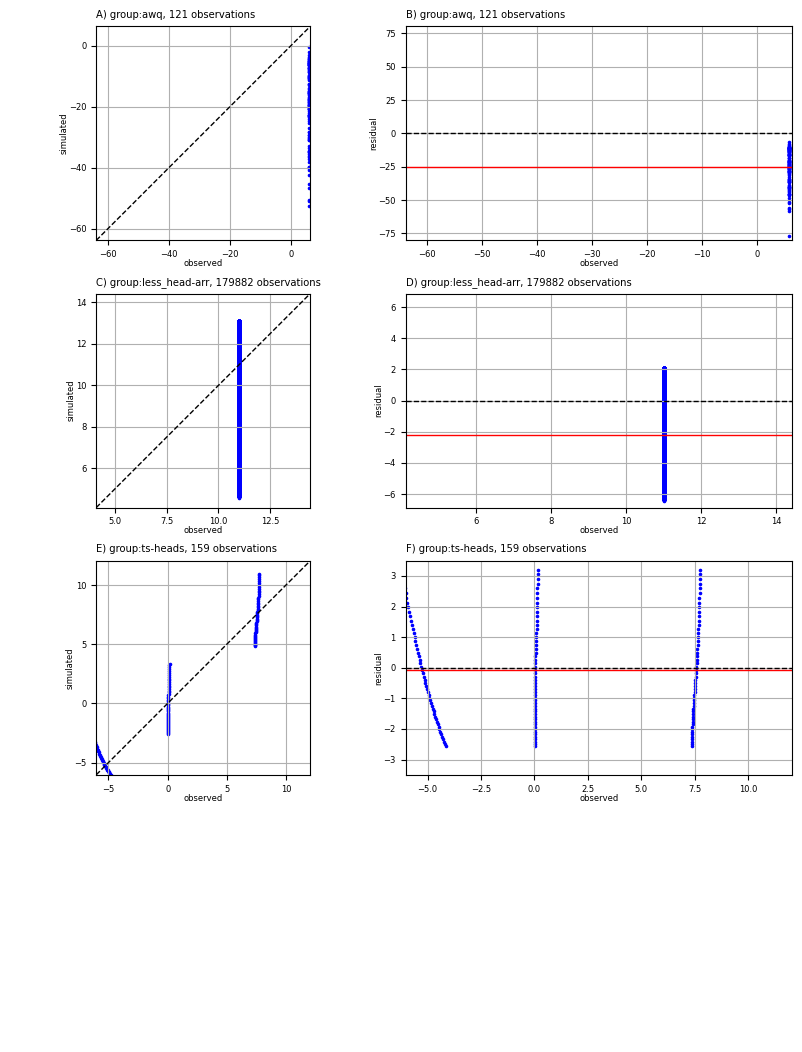

In [9]:
pst.plot('1to1')
plt.show()

### Phi (prior/posterior)

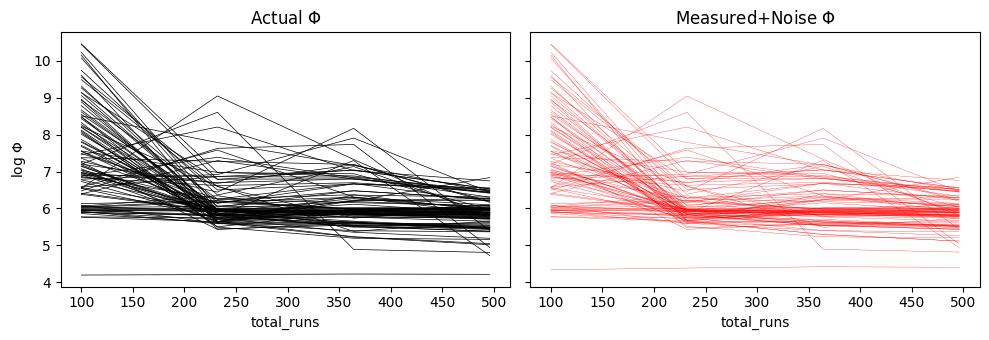

In [10]:
fig, axes = plt.subplots(1, 2, sharey=True, figsize=(10,3.5))
# left
ax = axes[0]
phi = pd.read_csv(f_act, index_col=0)
phi.index = phi.total_runs
phi.iloc[:,6:].apply(np.log10).plot(legend=False,lw=0.5,color='k', ax=ax)
ax.set_title(r'Actual $\Phi$')
ax.set_ylabel(r'log $\Phi$')
# right
ax = axes[-1]
phi = pd.read_csv(f_meas,index_col=0)
phi.index = phi.total_runs
phi.iloc[:,6:].apply(np.log10).plot(legend=False,lw=0.2,color='r', ax=ax)
ax.set_title(r'Measured+Noise $\Phi$')
fig.tight_layout()

# save
fig_fn = os.path.join(output, 'output.phi_comparison.png')
plt.savefig(fig_fn, dpi=300)

plt.show()

### Phi

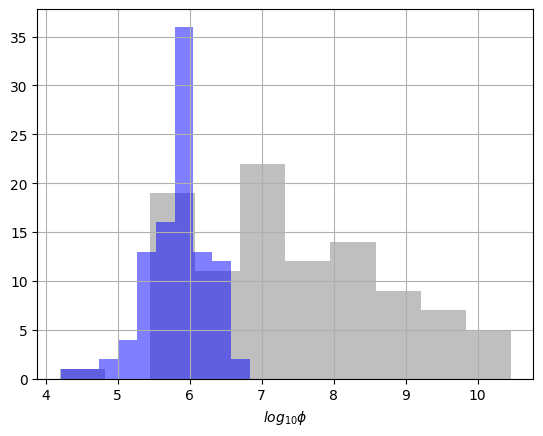

In [11]:
fig,ax = plt.subplots(1,1)
pr_oe.phi_vector.apply(np.log10).hist(ax=ax,fc="0.5",ec="none",alpha=0.5,density=False) # prior grey
pt_oe.phi_vector.apply(np.log10).hist(ax=ax,fc="b",ec="none",alpha=0.5,density=False) # posterior blue
_ = ax.set_xlabel("$log_{10}\\phi$")

plt.show()

### Budget

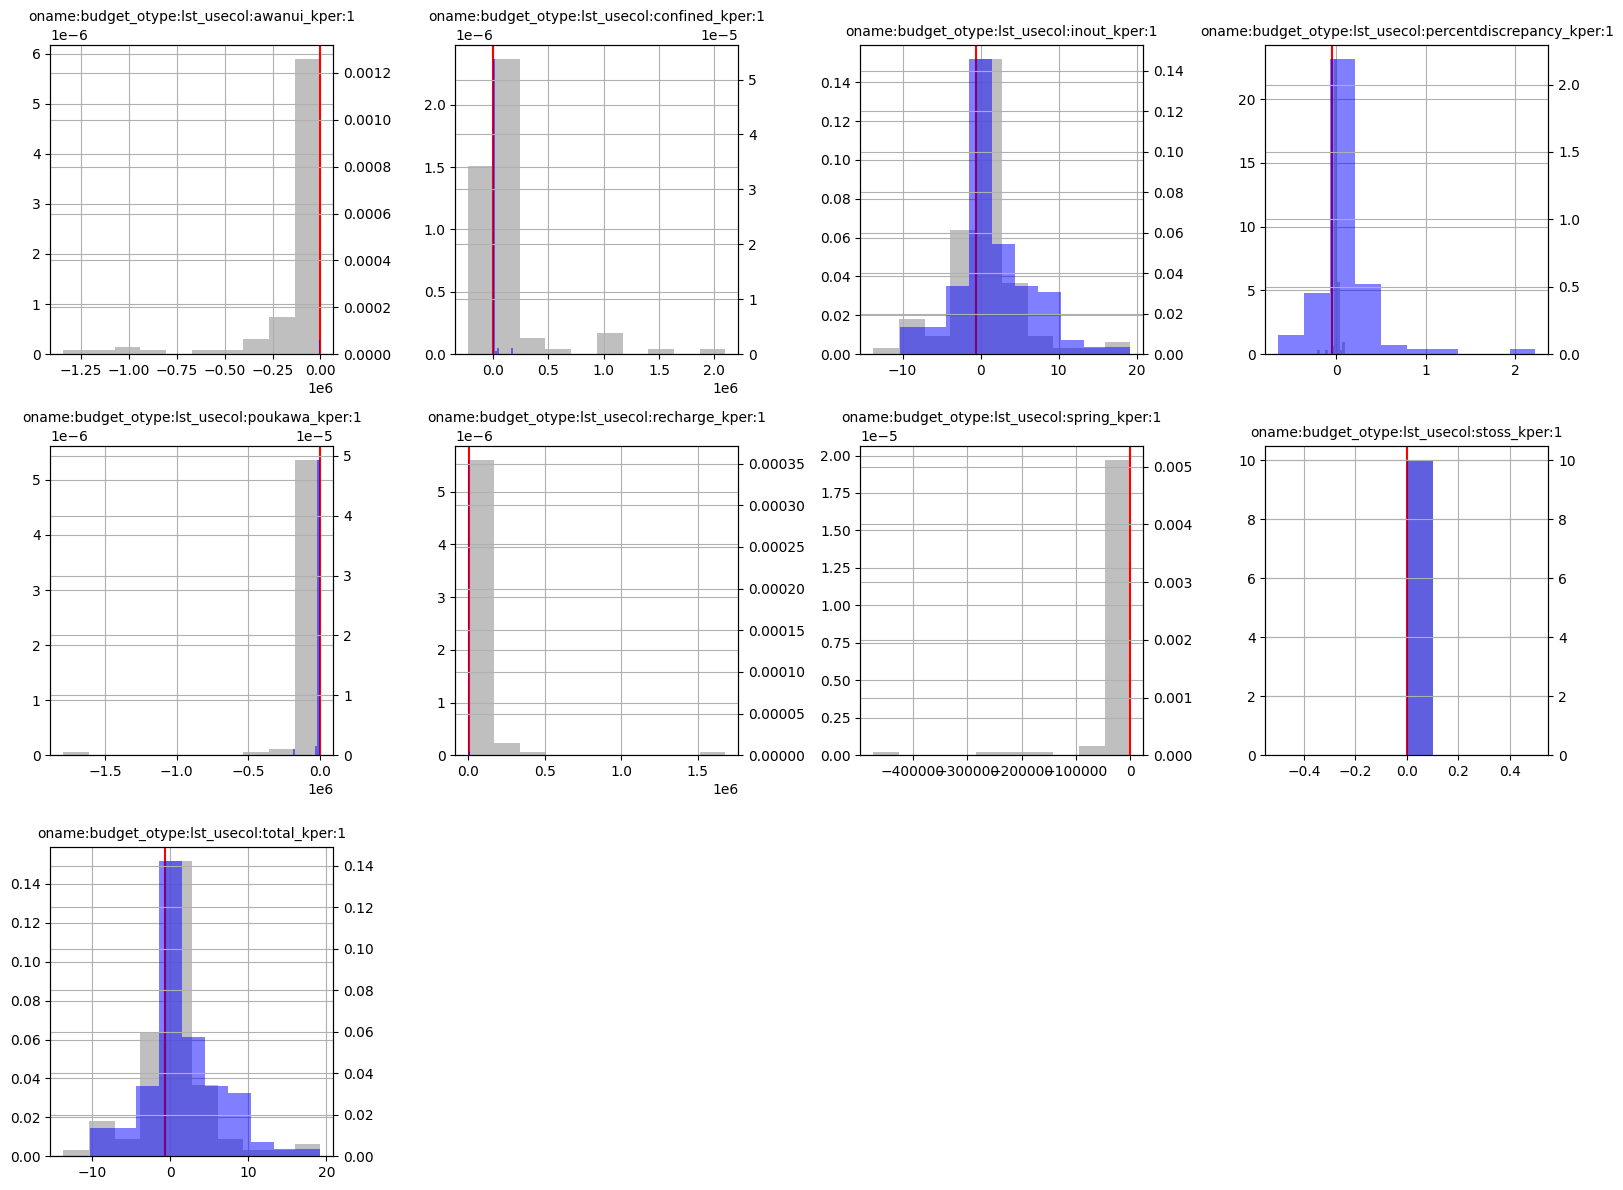

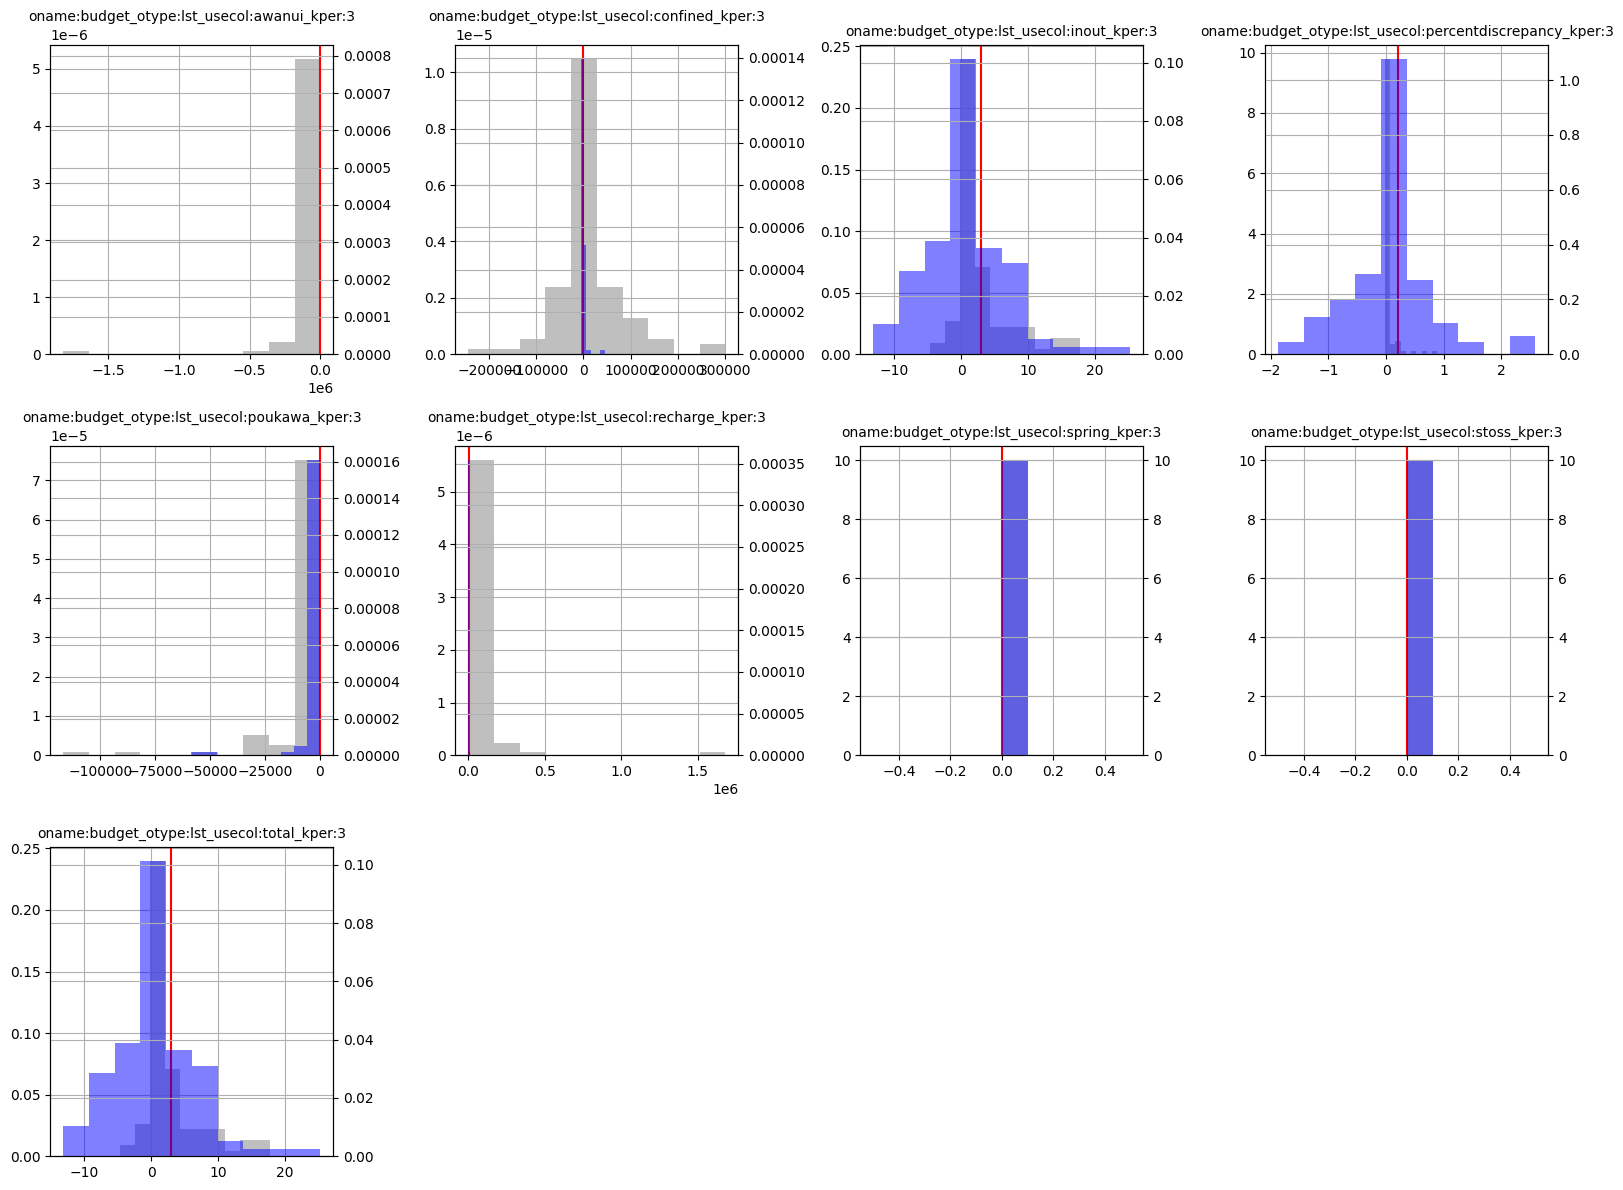

In [24]:
grp_start='oname:budget'
# Decide which columns you want to load
desired_cols1 = [col for col in headers if (col.startswith(grp_start) and col.endswith('1'))]
desired_cols3 = [col for col in headers if (col.startswith(grp_start) and col.endswith('3'))]

for desired_cols in [desired_cols1, desired_cols3]:
    kper = int(desired_cols[0].split('_')[-1].split(':')[-1])  # extract kper from the first 
    
    # Calculate subplot dimensions
    n_cols = 4
    n_plots = len(desired_cols)
    n_rows = (n_plots + n_cols - 1) // n_cols  # ceiling division
    
    # Create subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    
    # Handle case where we have only one row
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    elif n_plots == 1:
        axes = np.array([[axes]])
    
    # Flatten axes for easy iteration
    axes_flat = axes.flatten()
    
    for i, col in enumerate(desired_cols):
        ax = axes_flat[i]
        ax_b = ax.twinx()
        
        # plot the prior and posterior ensemble distributions
        pr_oe.loc[:, col].hist(ax=ax, fc="0.5", ec="none", alpha=0.5, density=True)  # prior grey
        pt_oe.loc[:, col].hist(ax=ax_b, fc="b", ec="none", alpha=0.5, density=True)  # posterior blue
        # plot x line
        ax.axvline(obs_data.loc[col, 'obsval'], color='red')
        ax.set_title(col, fontsize=10)
    
    # Hide empty subplots
    for i in range(n_plots, len(axes_flat)):
        axes_flat[i].set_visible(False)
    
    plt.tight_layout()

    # save
    fig_fn = os.path.join(output, f'output.budget_hist_kper{kper}.png')
    plt.savefig(fig_fn, dpi=300)
    plt.show()

### ts-heads

In [ ]:
grp_start='oname:ts-heads'
# Decide which columns you want to load
desired_cols1 = [col for col in headers if (col.startswith(grp_start))]
desired_cols3 = [col for col in headers if (col.startswith(grp_start) and col.endswith('3'))]

for desired_cols in [desired_cols1, desired_cols3]:
    kper = int(desired_cols[0].split('_')[-1].split(':')[-1])  # extract kper from the first 
    
    # Calculate subplot dimensions
    n_cols = 4
    n_plots = len(desired_cols)
    n_rows = (n_plots + n_cols - 1) // n_cols  # ceiling division
    
    # Create subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    
    # Handle case where we have only one row
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    elif n_plots == 1:
        axes = np.array([[axes]])
    
    # Flatten axes for easy iteration
    axes_flat = axes.flatten()
    
    for i, col in enumerate(desired_cols):
        ax = axes_flat[i]
        ax_b = ax.twinx()
        
        # plot the prior and posterior ensemble distributions
        pr_oe.loc[:, col].hist(ax=ax, fc="0.5", ec="none", alpha=0.5, density=True)  # prior grey
        pt_oe.loc[:, col].hist(ax=ax_b, fc="b", ec="none", alpha=0.5, density=True)  # posterior blue
        # plot x line
        ax.axvline(obs_data.loc[col, 'obsval'], color='red')
        ax.set_title(col, fontsize=10)
    
    # Hide empty subplots
    for i in range(n_plots, len(axes_flat)):
        axes_flat[i].set_visible(False)
    
    plt.tight_layout()

    # save
    fig_fn = os.path.join(output, f'output.budget_hist_kper{kper}.png')
    plt.savefig(fig_fn, dpi=300)
    plt.show()